# **Chuẩn Bị Và Xử Lý Bộ Dữ Liệu**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

In [ ]:
# Đường dẫn thư mục chứa ảnh
folder_path = "/content/drive/MyDrive/Recognition/Fingerprint_Recognition/Datasets/Fingerprint"

## **1. Giới thiệu bộ dữ liệu**

Trong bài toán nhận diện và so khớp dấu vân tay, chất lượng và đa dạng của dữ liệu đóng vai trò rất quan trọng. Để đảm bảo tính tổng quát và độ tin cậy của mô hình, nhóm em đã sử dụng tổng hợp từ nhiều bộ dữ liệu dấu vân tay công khai (public datasets), bao gồm:

#### **a. [FVC2000](http://bias.csr.unibo.it/fvc2000/download.asp), [FVC2002](http://bias.csr.unibo.it/fvc2002/download.asp), [FVC2004](http://bias.csr.unibo.it/fvc2004/download.asp)**

Các bộ dữ liệu thuộc cuộc thi **Fingerprint Verification Competition (FVC)** được thiết kế để đánh giá thuật toán xác thực dấu vân tay. Nhóm em chỉ sử dụng **phiên bản public** của mỗi bộ dữ liệu, được công bố chính thức và có thể tải về tự do mà không cần cấp phép thương mại hay chi phí.

Chúng em sử dụng nhiều phiên bản (2000, 2002, 2004) để gia tăng tính đa dạng và đảm bảo đủ lượng dữ liệu để mô hình có  thể học được.

**Cấu trúc và định dạng file ảnh**

* Bộ dữ liệu bao gồm 4 tập con (DB1–DB4), mỗi tập có **10 ngón tay**, mỗi ngón có **8 ảnh** (→ tổng cộng 320 ảnh mỗi bộ).
* Dữ liệu được lấy từ cảm biến quang học (optical).
* Mỗi ảnh là ảnh grayscale, định dạng **TIFF**.
* Tên file thường ở dạng:

  ```
  001_2.tif
  ```

  trong đó:

  * `001`: Mã số định danh cho một ngón tay cụ thể (có thể hiểu là ID ngón tay).
  * `2`: Ảnh quét lần thứ 2 trong tổng số 8 bản quét.

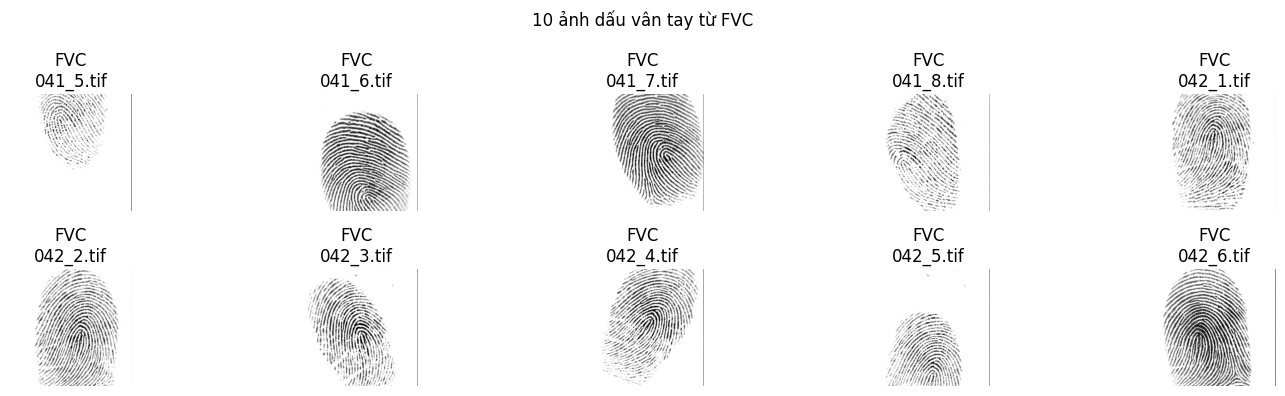

In [ ]:
fvc_images = []
for f in os.listdir(folder_path):
    if f.endswith(".tif") and f.count('_') == 1:
        fvc_images.append(f)
        if len(fvc_images) == 10:
            break

plt.figure(figsize=(15, 4))
for i, filename in enumerate(fvc_images):
    img = Image.open(os.path.join(folder_path, filename))
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"FVC\n{filename}")
    plt.axis('off')
plt.suptitle("10 ảnh dấu vân tay từ FVC")
plt.tight_layout()
plt.show()

#### **b. [SOCOFing (Sokoto Coventry Fingerprint Dataset)](https://www.kaggle.com/datasets/ruizgara/socofing)**

Bộ dữ liệu **SOCOFing** là một tập hợp dấu vân tay, do các trường đại học thu thập. Bộ dữ liệu này đặc biệt hữu ích trong các bài toán nhận diện và phát hiện dấu vân tay giả mạo (altered fingerprints), do nó bao gồm cả ảnh gốc và ảnh đã qua chỉnh sửa.

**Cấu trúc và định dạng file ảnh**:

* **6000 ảnh gốc** từ **600 cá nhân** (mỗi người 10 ngón tay).
* Cung cấp thêm **ảnh giả mạo (altered fingerprints)** với ba mức độ giả mạo: easy, medium, hard – dùng cho bài toán phát hiện giả mạo dấu vân tay (spoof detection).
* **Định dạng ảnh**: grayscale, 96×103 pixels.
* Bộ dữ liệu hoàn toàn mở và miễn phí sử dụng cho mục đích nghiên cứu.

* Tên file ở dạng:
    * Dạng 1: Ảnh gốc
      ```
      001__M_Right_thumb_finger.BMP
      ```

      Trong đó:
        
        * 001: ID của người
        * M: Male (gồm Male hoặc Female)
        * Right: Bàn tay phải (gồm Right hoặc Left)
        * thumb: tên ngón tay
    
    * Dạng 2: Ảnh qua chỉnh sửa
      ```
      001__M_Right_thumb_finger_Obl_1.BMP
      ```
      Trong đó:
        * 001: ID của người
        * M: Male (gồm Male hoặc Female)
        * Right: Bàn tay phải (gồm Right hoặc Left)
        * thumb: tên ngón tay
        * Obl: loại chỉnh sửa
        * 1: mức chỉnh sửa

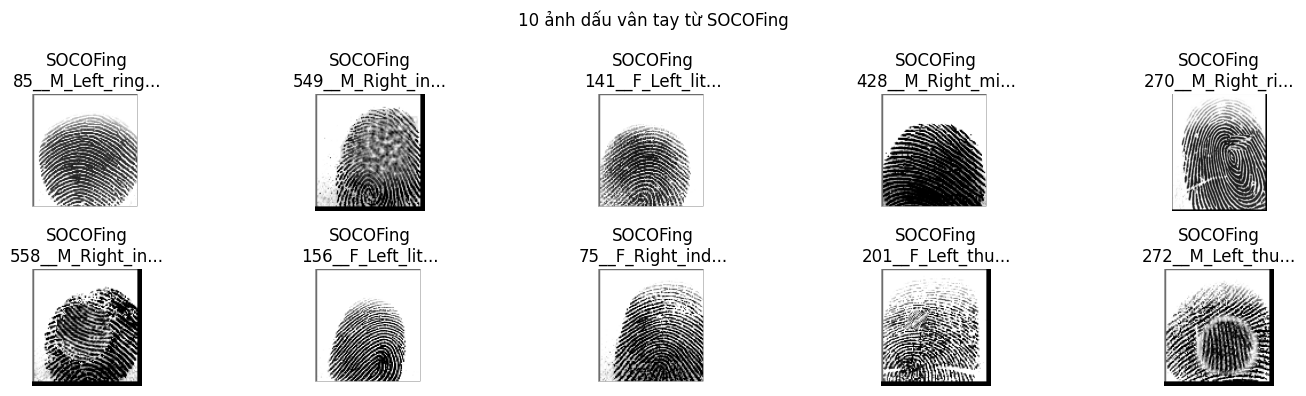

In [ ]:
socofing_images = []
for f in os.listdir(folder_path):
    if f.endswith(".BMP") and "__" in f:
        socofing_images.append(f)
        if len(socofing_images) == 10:
            break

plt.figure(figsize=(15, 4))
for i, filename in enumerate(socofing_images):
    img = Image.open(os.path.join(folder_path, filename))
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"SOCOFing\n{filename[:15]}...")
    plt.axis('off')
plt.suptitle("10 ảnh dấu vân tay từ SOCOFing")
plt.tight_layout()
plt.show()

#### **c. [Bộ dữ liệu từ cảm biến DigitalPersona U.are.U 4000](https://www.neurotechnology.com/fingerprint-scanner-digitalpersona-u-are-u-4000.html)**

Bộ dữ liệu này được thu thập từ thiết bị cảm biến dấu vân tay **DigitalPersona U.are.U 4000**, một cảm biến quang học phổ biến do công ty **Neurotechnology** hỗ trợ.

Thiết bị có độ phân giải **512 dpi**, hỗ trợ chụp ảnh dấu vân tay chất lượng cao ngay cả với vân tay khô, ướt hoặc mòn, đồng thời có khả năng loại bỏ ảnh giả mạo (spoof).


**Cấu trúc và định dạng file ảnh**

* Bộ dữ liệu bao gồm **7 người**, mỗi người **10 ngón tay**, mỗi ngón có **8 bản quét**, tổng cộng **560 ảnh**.
* Mỗi ảnh là ảnh grayscale, định dạng **TIFF**.
* Mỗi ảnh là ảnh **plain fingerprint** (ảnh chụp trực tiếp từ ngón tay đặt lên cảm biến, không cuộn).
* Tên file thường ở dạng:
  ```
  001_2_3.tif
  ```

  Trong đó:

  * `001` là mã định danh người,
  * `2` là mã định danh ngón tay (từ ngón thứ 1 đến ngón thứ 10).
  * `3` là phiên bản ảnh (từ 1 đến 8).

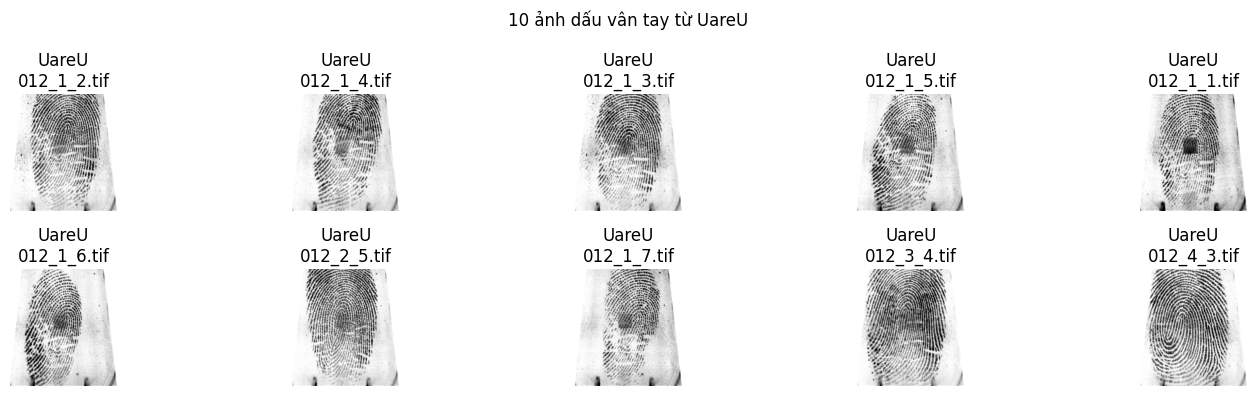

In [ ]:
uareu_images = []
for f in os.listdir(folder_path):
    if f.endswith(".tif") and f.count('_') == 2:
        uareu_images.append(f)
        if len(uareu_images) == 10:
            break

plt.figure(figsize=(15, 4))
for i, filename in enumerate(uareu_images):
    img = Image.open(os.path.join(folder_path, filename))
    plt.subplot(2, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.title(f"UareU\n{filename}")
    plt.axis('off')
plt.suptitle("10 ảnh dấu vân tay từ UareU")
plt.tight_layout()
plt.show()

####  Lý do sử dụng nhiều bộ dữ liệu

Vì bản public của mỗi FVC chỉ chứa một phần giới hạn số lượng ảnh (\~320x3 ảnh), nên nhóm em đã kết hợp chúng cùng với SOCOFing và U.are.U để:

* Tăng số lượng mẫu phục vụ huấn luyện và kiểm thử.
* Giúp mô hình học được đa dạng dấu vân tay từ nhiều nguồn thiết bị và người dùng khác nhau.
* Tăng khả năng tổng quát hoá (*generalization*) khi áp dụng mô hình vào thực tế.



## **2. Tạo bộ dữ liệu**


Bộ dữ liệu được xây dựng dưới dạng các **cặp ảnh**, với mục tiêu phục vụ cho bài toán **so khớp dấu vân tay**. Mỗi dòng dữ liệu gồm ba cột:

* **`img1`**: tên ảnh vân tay thứ nhất
* **`img2`**: tên ảnh vân tay thứ hai
* **`label`**: Nhãn nhị phân —

  * `1` nếu hai ảnh là của **cùng một ngón tay**,
  * `0` nếu là **khác ngón tay**.

#### **a. Nguyên tắc gán nhãn**

* Các cặp ảnh có nhãn `label = 1` được tạo từ **các phiên bản khác nhau của cùng một ngón tay**, ví dụ như `001_1.tif` và `001_6.tif`.
* Các cặp ảnh có nhãn `label = 0` được tạo từ **những ngón tay khác nhau**, thậm chí có thể thuộc những người khác nhau.

Việc gán nhãn được kiểm soát chặt chẽ nhằm đảm bảo:

* Không có ảnh bị trùng trong cùng một dòng.
* Các cặp không lặp lại theo thứ tự (tức là `(img1, img2)` và `(img2, img1)` không cùng tồn tại).

#### **b. Số lượng và phân bổ nhãn**

##### **Bộ dữ liệu FVC (Fingerprint Verification Competition)**

* Mỗi ngón tay trong FVC có **8 ảnh**, từ đó tạo ra **28 cặp có cùng ngón tay** theo tổ hợp `C(8, 2) = 28`.
* Vì dữ liệu nhãn `1` khá hạn chế, nên nhóm chọn tất cả các cặp `label = 1` sinh ra từ bộ FVC.
* Bên cạnh đó, để tăng tính đa dạng và khả năng phân biệt giữa các dấu vân tay, nhóm chủ động lấy thêm **7.500 cặp khác ngón tay (label = 0)** từ bộ FVC, tạo nên sự mất cân bằng có chủ đích nhằm hỗ trợ mô hình học tốt hơn.

##### **Bộ dữ liệu U.are.U 4000**

* Cơ chế tương tự như FVC: mỗi ngón tay có 8 ảnh → 28 cặp nhãn `1` cho mỗi ngón.
* Tất cả các cặp cùng ngón tay đều được đưa vào tập dữ liệu, góp phần mở rộng số lượng cặp so khớp dương (label `1`).

##### **Bộ dữ liệu SOCOFing**

* Dù bộ dữ liệu này có nhiều ảnh và mức độ chỉnh sửa ảnh khác nhau, tuy nhiên các ảnh được chỉnh sửa dựa trên ảnh gốc (không phải ảnh chụp khác).
* Nhằm đảm bảo tính đại diện mà vẫn kiểm soát được nhiễu, nhóm chọn **2500 cặp có cùng ngón tay (label = 1)** một cách ngẫu nhiên.
* Tương ứng, nhóm cũng lấy **2500 cặp khác ngón tay (label = 0)** từ SOCOFing để cân bằng nhãn trong tập này.


#### **c. Chiến lược phân bổ nhãn và lý do**

Do đặc thù bài toán **so khớp dấu vân tay** là mô hình cần học được sự khác biệt rõ ràng giữa các ngón tay khác nhau, nên việc cung cấp **nhiều cặp `label = 0` hơn `label = 1`** là chủ đích:

* Giúp mô hình **học phân lớp ranh mạnh hơn** giữa dấu vân tay không trùng.
* Hạn chế việc mô hình học thuộc lòng các đặc điểm chung chung của ảnh.
* Tăng độ đa dạng và khó khăn trong quá trình huấn luyện, làm tăng **khả năng tổng quát hóa** khi áp dụng mô hình cho dữ liệu thực tế.


#### **d. Tóm tắt phân bổ dữ liệu**

| Bộ dữ liệu    | Số cặp `label = 1`                   | Số cặp `label = 0` |
| ------------- | ------------------------------------ | ------------------ |
| FVC           | ≈ 3500                               | **7500**           |
| U.are.U 4000  | ≈ 1700                               | ≈ 3000             |
| SOCOFing      | **2.500**                            | **2.500**          |
| **Tổng cộng** | \~7700                               | \~13.000           |





## **3. Chia bộ dữ liệu huấn luyện và đánh giá mô hình**

Sau khi tổng hợp toàn bộ cặp ảnh với nhãn tương ứng, bộ dữ liệu được chia thành **hai phần**:
* **Tập đánh giá (evaluation/validation set)**:

  * Gồm **1000 cặp có nhãn `label = 1`** (cùng ngón tay)
  * Và **1000 cặp có nhãn `label = 0`** (khác ngón tay)
  * Các cặp được **chọn ngẫu nhiên** từ toàn bộ tập dữ liệu đã chuẩn bị.

* **Tập huấn luyện (training set)**:

  * Bao gồm **toàn bộ phần còn lại** sau khi đã tách tập đánh giá.



Ta phải đảm bảo các cặp trong tập đánh giá **không trùng lặp** với tập huấn luyện.



In [ ]:
import pandas as pd

# Dữ liệu train
df1 = pd.read_csv('/content/pairs_train.csv')

# Dữ liệu test
df2 = pd.read_csv('/content/pairs_test.csv')

In [ ]:
# In số bộ
print("Số cặp vân tay huấn luyện:", len(df1))
print("Số cặp vân tay đánh giá:", len(df2))

Số cặp vân tay huấn luyện: 20877
Số cặp vân tay đánh giá: 2000


In [ ]:
# Tìm các dòng giống nhau giữa df1 và df2
duplicates = pd.merge(df1, df2, on=['img1', 'img2', 'label'])

# In số dòng trùng
print("Số dòng trùng nhau giữa df1 và df2:", len(duplicates))

# Nếu có, in một vài dòng để xem
if not duplicates.empty:
    print("Một số dòng trùng:")
    print(duplicates.head())
else:
    print("Không có dòng nào trùng giữa df1 và df2.")

Số dòng trùng nhau giữa df1 và df2: 0
Không có dòng nào trùng giữa df1 và df2.


## **4. Tạo database để truy vấn**

Sau khi hoàn thành quá trình xây dựng và huấn luyện mô hình so khớp dấu vân tay, một trong những ứng dụng quan trọng là **truy vấn và nhận diện**:

> *Cho một ảnh dấu vân tay đầu vào, mô hình có thể tìm ra những ảnh tương đồng nhất từ một cơ sở dữ liệu (database) đã biết.*

Mục tiêu của việc tạo **database dấu vân tay** là:

* Làm đầu vào cho bài toán **truy vấn Top‑K ảnh tương đồng**.
* Giúp đánh giá **khả năng tổng quát hóa và độ chính xác thực tế** của mô hình.
* Mô phỏng quá trình nhận dạng dấu vân tay thực tế: tìm ra người đúng từ cơ sở dữ liệu đã đăng ký.

#### **Nguồn dữ liệu**

Database được tạo từ bộ dữ liệu **DigitalPersona U.are.U 4000**, do đây là bộ dữ liệu thu thập thực tế từ máy quét dấu vân tay phổ biến.

Cụ thể, nhóm lựa chọn:

* **7 người** từ tập dữ liệu
* Mỗi người có **10 ngón tay**
* Với **mỗi ngón chỉ chọn ảnh scan đầu tiên** (phiên bản 1)
  → Tổng cộng **70 ảnh** tạo thành **database dùng để truy vấn**

Sau khi mô hình được huấn luyện xong, quá trình truy vấn hoạt động như sau:

1. **Đầu vào**: Một ảnh dấu vân tay bất kỳ (không nằm trong database, có thể là phiên bản khác của cùng ngón tay trong database).
2. **Xử lý**: Mô hình tính **độ tương đồng** giữa ảnh đầu vào và từng ảnh trong database.
3. **Kết quả**: Trả về **Top‑K ảnh** có điểm tương đồng cao nhất (theo mô hình dự đoán).
4. **Ứng dụng**: Dùng trong **xác thực danh tính**, **đề xuất người dùng phù hợp**, hoặc làm bước đầu trong pipeline nhận diện.




## **5. Trực quan**

In [ ]:
# Lấy 5 cặp có label = 1
df_positive = df2[df2['label'] == 1].head(2)
# Lấy 5 cặp có label = 0
df_negative = df2[df2['label'] == 0].head(2)

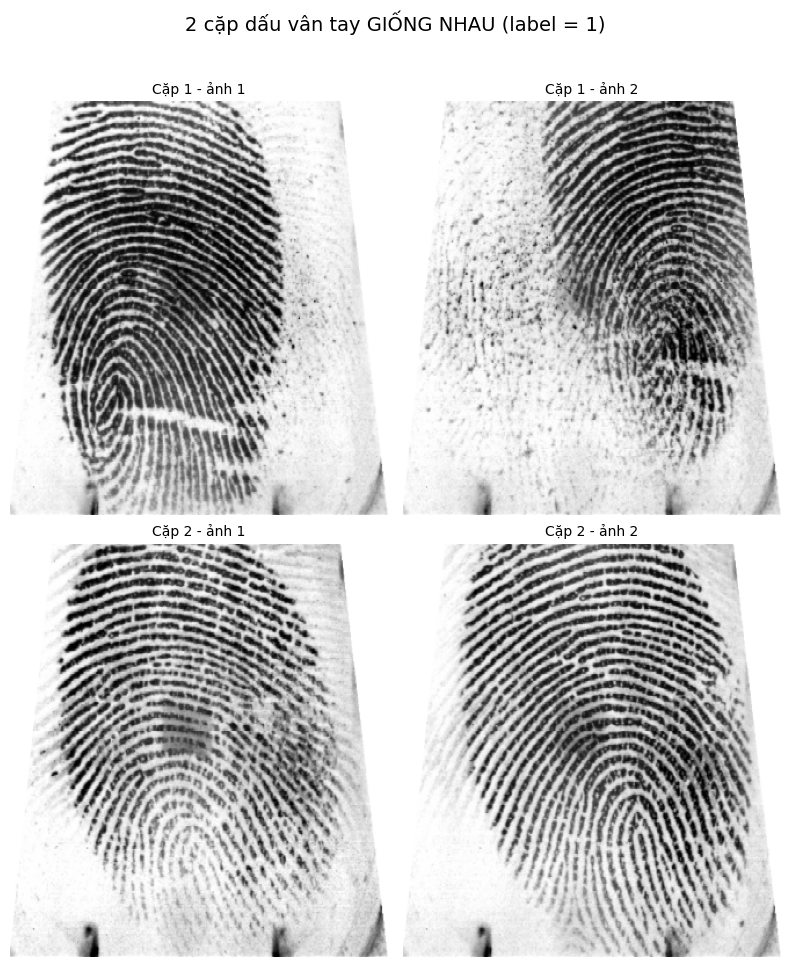

In [ ]:
# Hiển thị 5 cặp ảnh (giống nhau)
plt.figure(figsize=(8, 10))
for idx, row in enumerate(df_positive.itertuples()):
    img1 = Image.open(os.path.join(folder_path, row.img1))
    img2 = Image.open(os.path.join(folder_path, row.img2))

    # Ảnh thứ nhất
    plt.subplot(2, 2, idx * 2 + 1)
    plt.imshow(img1, cmap='gray')
    plt.title(f"Cặp {idx + 1} - ảnh 1", fontsize=10)
    plt.axis('off')

    # Ảnh thứ hai
    plt.subplot(2, 2, idx * 2 + 2)
    plt.imshow(img2, cmap='gray')
    plt.title(f"Cặp {idx + 1} - ảnh 2", fontsize=10)
    plt.axis('off')

plt.suptitle("2 cặp dấu vân tay GIỐNG NHAU (label = 1)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

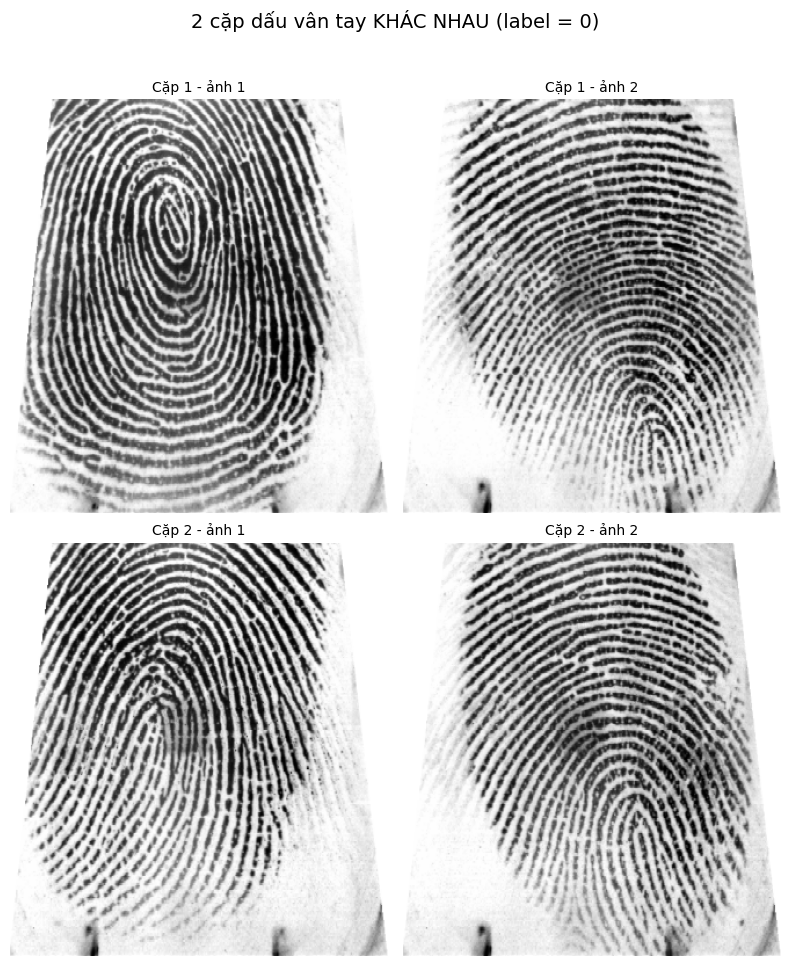

In [ ]:
# Hiển thị 5 cặp ảnh (khác nhau)
plt.figure(figsize=(8, 10))
for idx, row in enumerate(df_negative.itertuples()):
    img1 = Image.open(os.path.join(folder_path, row.img1))
    img2 = Image.open(os.path.join(folder_path, row.img2))

    # Ảnh thứ nhất
    plt.subplot(2, 2, idx * 2 + 1)
    plt.imshow(img1, cmap='gray')
    plt.title(f"Cặp {idx + 1} - ảnh 1", fontsize=10)
    plt.axis('off')

    # Ảnh thứ hai
    plt.subplot(2, 2, idx * 2 + 2)
    plt.imshow(img2, cmap='gray')
    plt.title(f"Cặp {idx + 1} - ảnh 2", fontsize=10)
    plt.axis('off')

plt.suptitle("2 cặp dấu vân tay KHÁC NHAU (label = 0)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()